# Cycle 3 - EDA and Group Summary

**Research question:** Is the proportion of students who felt sad or hopeless different between male and female students?

This notebook uses the cleaned dataset from `data/processed/cycle3_selected_variables.csv` and produces descriptive summaries and EDA figures for the two selected variables.

**Variable coding after cleaning:**

| Variable | Code | Meaning |
|---|---:|---|
| `WhatIsYourSex` | 1 | Female |
| `WhatIsYourSex` | 0 | Male |
| `SadOrHopeless` | 1 | Yes |
| `SadOrHopeless` | 0 | No |


## 1. Import Packages and Load Cleaned Data

The cleaned dataset was created in the previous notebook. This step checks the file, loads the selected variables, and creates the output folders for tables and figures.


In [1]:
# ============================================
# Cycle 3 - EDA and Group Summary
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Set paths
processed_path = Path("../data/processed/cycle3_selected_variables.csv")
table_dir = Path("../outputs/tables")
fig_dir = Path("../outputs/figures")

table_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# Load cleaned data
if not processed_path.exists():
    raise FileNotFoundError(
        f"Cannot find {processed_path}. Run 01_Cycle3 notebook first to create the cleaned data file."
    )

df_analysis = pd.read_csv(processed_path)

print("Cleaned data shape:", df_analysis.shape)
display(df_analysis.head())


Cleaned data shape: (13833, 2)


,WhatIsYourSex,SadOrHopeless
0,0,1
1,0,0
2,0,1
3,1,1
4,1,1


## 2. Check Recoded Variables

Before making tables or charts, check whether the two binary variables only contain the expected values: `0` and `1`.


In [2]:
# ============================================
# Check Recoded Variables
# ============================================

required_columns = ["WhatIsYourSex", "SadOrHopeless"]
missing_columns = [col for col in required_columns if col not in df_analysis.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("WhatIsYourSex frequency:")
display(df_analysis["WhatIsYourSex"].value_counts(dropna=False).sort_index())

print("SadOrHopeless frequency:")
display(df_analysis["SadOrHopeless"].value_counts(dropna=False).sort_index())

# Check unexpected codes after cleaning and recoding
expected_codes = {0, 1}
sex_codes = set(df_analysis["WhatIsYourSex"].dropna().unique())
sad_codes = set(df_analysis["SadOrHopeless"].dropna().unique())

print("Unexpected WhatIsYourSex codes:", sex_codes - expected_codes)
print("Unexpected SadOrHopeless codes:", sad_codes - expected_codes)


WhatIsYourSex frequency:


WhatIsYourSex
0    6893
1    6940
Name: count, dtype: int64

SadOrHopeless frequency:


SadOrHopeless
0    9686
1    4147
Name: count, dtype: int64

Unexpected WhatIsYourSex codes: set()
Unexpected SadOrHopeless codes: set()


## 3. Add Readable Labels

The original analysis columns keep the numeric coding. Readable labels are added only for summaries and charts.


In [3]:
# ============================================
# Add Labels for EDA
# ============================================

# WhatIsYourSex:
# 1 = Female
# 0 = Male
df_analysis["sex_label"] = df_analysis["WhatIsYourSex"].map({
    1: "Female",
    0: "Male"
})

# SadOrHopeless:
# 1 = Yes
# 0 = No
df_analysis["sad_label"] = df_analysis["SadOrHopeless"].map({
    1: "Sad/Hopeless = Yes",
    0: "Sad/Hopeless = No"
})

print("Label check:")
display(df_analysis[["WhatIsYourSex", "sex_label", "SadOrHopeless", "sad_label"]].head())


Label check:


,WhatIsYourSex,sex_label,SadOrHopeless,sad_label
0,0,Male,1,Sad/Hopeless = Yes
1,0,Male,0,Sad/Hopeless = No
2,0,Male,1,Sad/Hopeless = Yes
3,1,Female,1,Sad/Hopeless = Yes
4,1,Female,1,Sad/Hopeless = Yes


## 4. Four-Group Summary

Because both variables are binary, combining them creates four groups:

1. Female / Sad or hopeless = Yes  
2. Female / Sad or hopeless = No  
3. Male / Sad or hopeless = Yes  
4. Male / Sad or hopeless = No  

This table describes the overall distribution of the four combinations.


In [4]:
# ============================================
# Four-Group Proportion Summary
# ============================================

# Create four-group label
df_analysis["group_label"] = (
    df_analysis["sex_label"] + " / " + df_analysis["sad_label"]
)

# Count each group
four_group_summary = (
    df_analysis["group_label"]
    .value_counts()
    .reset_index()
)

four_group_summary.columns = ["group_label", "count"]

# Calculate proportion of total sample
four_group_summary["proportion_of_total"] = (
    four_group_summary["count"] / len(df_analysis)
)

four_group_summary["percentage_of_total"] = (
    four_group_summary["proportion_of_total"] * 100
).round(2)

# Set display order
group_order = [
    "Female / Sad/Hopeless = Yes",
    "Female / Sad/Hopeless = No",
    "Male / Sad/Hopeless = Yes",
    "Male / Sad/Hopeless = No"
]

four_group_summary["group_label"] = pd.Categorical(
    four_group_summary["group_label"],
    categories=group_order,
    ordered=True
)

four_group_summary = four_group_summary.sort_values("group_label").reset_index(drop=True)

print("Four-group summary:")
display(four_group_summary)

# Save summary table
four_group_summary.to_csv(
    table_dir / "cycle3_four_group_proportion_summary.csv",
    index=False
)


Four-group summary:


,group_label,count,proportion_of_total,percentage_of_total
0,Female / Sad/Hopeless = Yes,2580,0.186511,18.65
1,Female / Sad/Hopeless = No,4360,0.315188,31.52
2,Male / Sad/Hopeless = Yes,1567,0.113280,11.33
3,Male / Sad/Hopeless = No,5326,0.385021,38.50


## 5. Four-Group Proportion Bar Chart

This chart shows the proportion of the total cleaned sample in each of the four sex-by-response combinations.


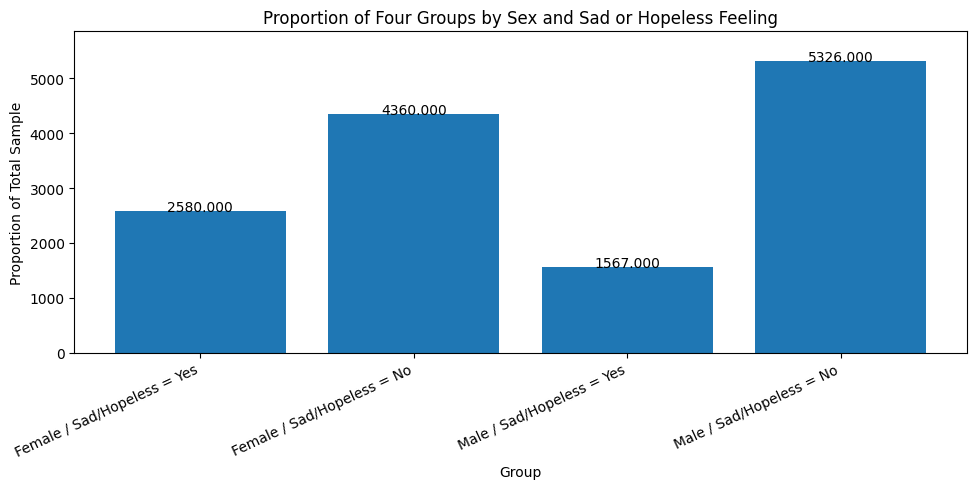

In [5]:
# ============================================
# Bar Chart: Four-Group Proportion
# ============================================

plt.figure(figsize=(10, 5))

plt.bar(
    four_group_summary["group_label"].astype(str),
    four_group_summary["count"]
)

plt.title("Proportion of Four Groups by Sex and Sad or Hopeless Feeling")
plt.xlabel("Group")
plt.ylabel("Proportion of Total Sample")

plt.ylim(0, four_group_summary["count"].max() * 1.1)
plt.xticks(rotation=25, ha="right")

# Add value labels
for i, value in enumerate(four_group_summary["count"]):
    plt.text(
        i,
        value + 0.001,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    fig_dir / "cycle3_four_group_proportion_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6. Within-Gender Proportion Summary

The research question compares the **proportion who felt sad or hopeless within each gender**. Therefore, this table is more directly related to the later two-proportion z-test.


In [6]:
# ============================================
# Within-Gender Proportion Summary
# ============================================

within_gender_summary = (
    df_analysis
    .groupby(["sex_label", "sad_label"])
    .size()
    .reset_index(name="count")
)

# Calculate proportion within each gender
within_gender_summary["within_gender_proportion"] = (
    within_gender_summary["count"] /
    within_gender_summary.groupby("sex_label")["count"].transform("sum")
)

within_gender_summary["within_gender_percentage"] = (
    within_gender_summary["within_gender_proportion"] * 100
).round(2)

# Sort order
within_gender_summary["sex_label"] = pd.Categorical(
    within_gender_summary["sex_label"],
    categories=["Female", "Male"],
    ordered=True
)

within_gender_summary["sad_label"] = pd.Categorical(
    within_gender_summary["sad_label"],
    categories=["Sad/Hopeless = Yes", "Sad/Hopeless = No"],
    ordered=True
)

within_gender_summary = within_gender_summary.sort_values(
    ["sex_label", "sad_label"]
).reset_index(drop=True)

print("Within-gender summary:")
display(within_gender_summary)

# Save table
within_gender_summary.to_csv(
    table_dir / "cycle3_within_gender_proportion_summary.csv",
    index=False
)


Within-gender summary:


,sex_label,sad_label,count,within_gender_proportion,within_gender_percentage
0,Female,Sad/Hopeless = Yes,2580,0.371758,37.18
1,Female,Sad/Hopeless = No,4360,0.628242,62.82
2,Male,Sad/Hopeless = Yes,1567,0.227332,22.73
3,Male,Sad/Hopeless = No,5326,0.772668,77.27


## 7. Within-Gender Proportion Bar Chart

This chart compares the Yes/No proportions inside each gender group. It is useful for explaining the direction of the difference before doing formal inference.


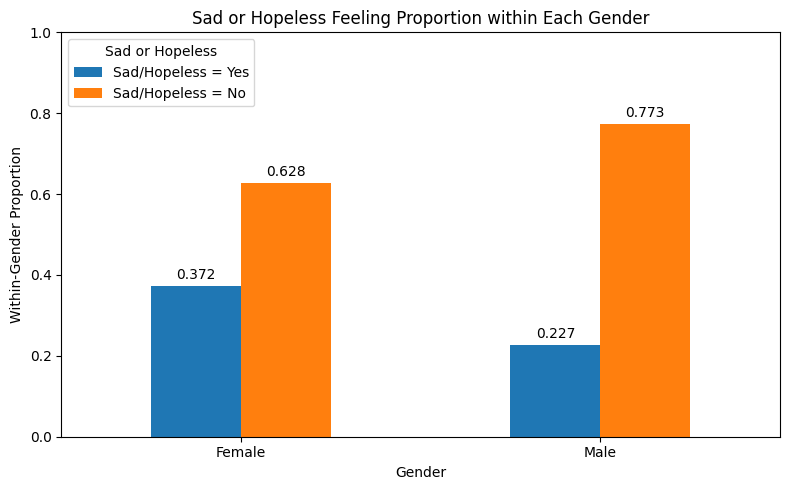

In [7]:
# ============================================
# Bar Chart: Within-Gender Proportion
# ============================================

pivot_summary = within_gender_summary.pivot(
    index="sex_label",
    columns="sad_label",
    values="within_gender_proportion"
)

pivot_summary = pivot_summary.loc[["Female", "Male"]]
pivot_summary = pivot_summary[["Sad/Hopeless = Yes", "Sad/Hopeless = No"]]

ax = pivot_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sad or Hopeless Feeling Proportion within Each Gender")
plt.xlabel("Gender")
plt.ylabel("Within-Gender Proportion")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Sad or Hopeless")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()

plt.savefig(
    fig_dir / "cycle3_within_gender_proportion_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 8. Short EDA Interpretation

The four-group summary describes the total distribution of sex and sad/hopeless response combinations. The within-gender summary is the main descriptive comparison for this research question because it compares the proportion of `Sad/Hopeless = Yes` separately for female and male students.

The next notebook should use these group counts and proportions to run the two-proportion z-test and construct a confidence interval for the difference in proportions.
